### **CodeAlpha - Task 1**

### Step 1: Iris Flower Classification

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Libraries imported successfully!")

Libraries imported successfully!


###Step 2: Load the Iris Dataset

In [11]:
# Load the built-in Iris dataset
iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the target/species column
df["species"] = iris.target

# Convert numeric targets to flower names
df["species_name"] = df["species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

# Display the first 10 rows
print("First 10 rows of the Iris dataset:")
display(df.head(10))

# Display dataset information
print("\nDataset shape:", df.shape)

print("\nSpecies distribution:")
print(df["species_name"].value_counts())

First 10 rows of the Iris dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa
5,5.4,3.9,1.7,0.4,0,Setosa
6,4.6,3.4,1.4,0.3,0,Setosa
7,5.0,3.4,1.5,0.2,0,Setosa
8,4.4,2.9,1.4,0.2,0,Setosa
9,4.9,3.1,1.5,0.1,0,Setosa



Dataset shape: (150, 6)

Species distribution:
species_name
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


### Step 3: Exploratory Data Analysis

In [12]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Statistical summary
print("\nStatistical Summary:")
display(df.describe())

# Check the data types
print("\nData Types:")
print(df.dtypes)

Missing values in each column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000



Data Types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
species_name          object
dtype: object


### Step 4: Data Visualization

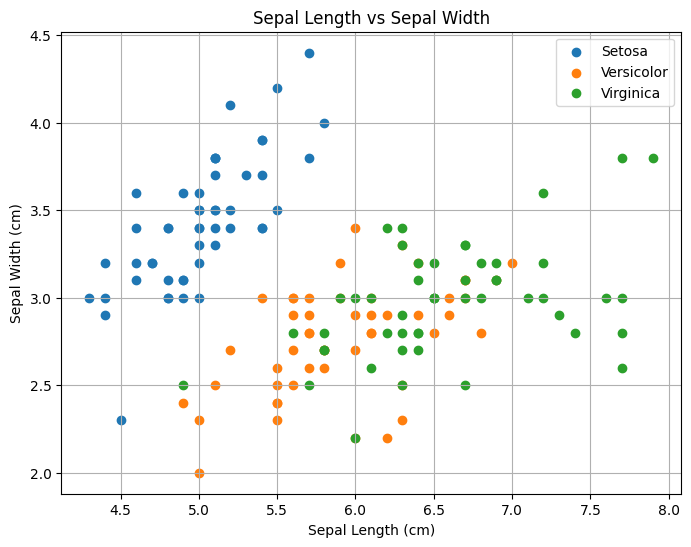

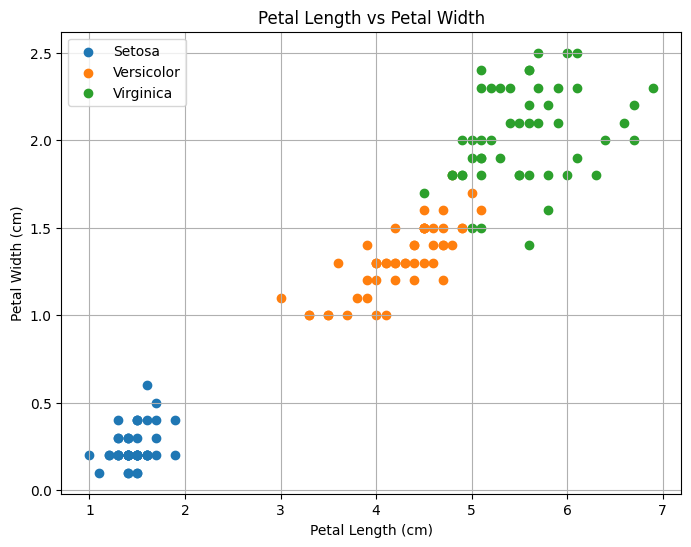

In [13]:
# Plot 1: Sepal Length vs Sepal Width
plt.figure(figsize=(8, 6))

for species in df["species_name"].unique():
    subset = df[df["species_name"] == species]
    plt.scatter(
        subset["sepal length (cm)"],
        subset["sepal width (cm)"],
        label=species
    )

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.title("Sepal Length vs Sepal Width")
plt.legend()
plt.grid(True)
plt.show()


# Plot 2: Petal Length vs Petal Width
plt.figure(figsize=(8, 6))

for species in df["species_name"].unique():
    subset = df[df["species_name"] == species]
    plt.scatter(
        subset["petal length (cm)"],
        subset["petal width (cm)"],
        label=species
    )

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Petal Length vs Petal Width")
plt.legend()
plt.grid(True)
plt.show()

### Step 5: Prepare Data and Train ML Model

In [14]:
# Select input features
X = df[[
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)"
]]

# Select target variable
y = df["species"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create Logistic Regression model
model = LogisticRegression(max_iter=200)

# Train the model
model.fit(X_train_scaled, y_train)

print("\nModel training completed successfully!")

Training samples: 120
Testing samples: 30

Model training completed successfully!


### Step 6: Model Evaluation

In [15]:
# Make predictions on the test data
y_pred = model.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

Model Accuracy: 93.33%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



### Step 7: Confusion Matrix

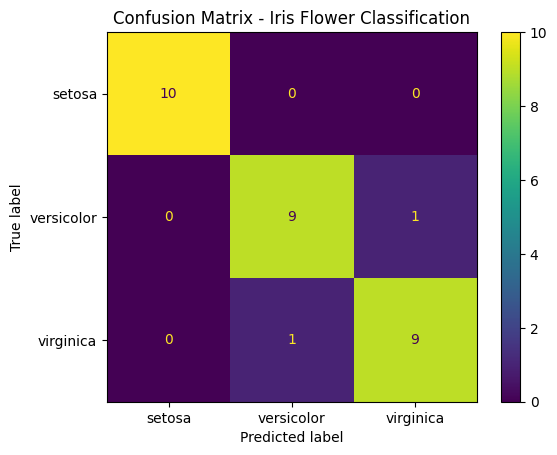

In [16]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()
plt.title("Confusion Matrix - Iris Flower Classification")
plt.show()

### tep 8: Predict a New Iris Flower

In [17]:
# Example flower measurements:
# [sepal length, sepal width, petal length, petal width]

new_flower = [[5.1, 3.5, 1.4, 0.2]]

# Scale the new data using the same scaler
new_flower_scaled = scaler.transform(new_flower)

# Make prediction
prediction = model.predict(new_flower_scaled)

# Get predicted flower name
predicted_species = iris.target_names[prediction[0]]

print("New Flower Measurements:")
print("Sepal Length: 5.1 cm")
print("Sepal Width: 3.5 cm")
print("Petal Length: 1.4 cm")
print("Petal Width: 0.2 cm")

print("\nPredicted Species:", predicted_species.capitalize())

New Flower Measurements:
Sepal Length: 5.1 cm
Sepal Width: 3.5 cm
Petal Length: 1.4 cm
Petal Width: 0.2 cm

Predicted Species: Setosa


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### Step 8: Predict a New Iris Flower

In [18]:
# Create new flower data with the same feature names
new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=[
        "sepal length (cm)",
        "sepal width (cm)",
        "petal length (cm)",
        "petal width (cm)"
    ]
)

# Scale the new flower data
new_flower_scaled = scaler.transform(new_flower)

# Make prediction
prediction = model.predict(new_flower_scaled)

# Convert prediction to flower name
predicted_species = iris.target_names[prediction[0]]

print("New Flower Measurements:")
display(new_flower)

print("\nPredicted Species:", predicted_species.capitalize())

New Flower Measurements:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2



Predicted Species: Setosa
